I use two data sources:<br>
[County Population Totals and Components of Change: 2020-
2025](https://www.census.gov/data/tables/time-series/demo/popest/2020s-counties-total.html)<br>
[Excel file](https://www2.census.gov/programs-surveys/popest/tables/2020-
2025/counties/totals/co-est2025-pop.xlsx)<br>
[Zillow Housing Data](https://www.zillow.com/research/data/) <br>
[csv
file](https://files.zillowstatic.com/research/public_csvs/zhvi/County_zhvi_uc_sfrcondo_tier_0.33_0.
67_sm_sa_month.csv?t=1775837851)

The code below imports county-level data from Zillow (named "housing") and the Census Bureau
(named "pop"). For housing, we use the data from December 2020. In the dataset, housing prices
are labeled as "hp" and population data is labeled as "pop".

In [1]:
suppressWarnings(suppressMessages({
library(dplyr); library(ggplot2); library(readxl); library(ggrepel); options(warn = -1)
options(repr.plot.width = 15, repr.plot.height = 9)
zillow_data = 'https://files.zillowstatic.com/research/public_csvs/zhvi/County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv?t=1775837851'
pop_data = 'https://www2.census.gov/programs-surveys/popest/tables/2020-2025/counties/totals/co-est2025-pop.xlsx'
housing = read.csv(zillow_data) %>% mutate(State = state.name[match(State, state.abb)],
name = paste0(RegionName, ', ', State)) %>%
select(name, contains("12.31") & contains("202")) %>%
rename_with(~ paste0("hp", 2020:2025), 2:7) %>% na.omit()
ct_crosswalk = data.frame( # Connecticut County names
planning_region = c("Capitol Planning Region, Connecticut", "Greater Bridgeport Planning Region, Connecticut",
"Lower Connecticut River Valley Planning Region, Connecticut", "Naugatuck Valley Planning Region, Connecticut",
"Northeastern Connecticut Planning Region, Connecticut", "Northwest Hills Planning Region, Connecticut",
"South Central Connecticut Planning Region, Connecticut", "Southeastern Connecticut Planning Region, Connecticut",
"Western Connecticut Planning Region, Connecticut"),
legacy_county = c(
"Hartford County, Connecticut", "Fairfield County, Connecticut", "Middlesex County, Connecticut",
"New Haven County, Connecticut", "Windham County, Connecticut", "Litchfield County, Connecticut",
"New Haven County, Connecticut", "New London County, Connecticut", "Fairfield County, Connecticut"))
housing = housing %>% left_join(ct_crosswalk, by = c("name" = "legacy_county")) %>%
mutate(name = ifelse(!is.na(planning_region), planning_region, name)) %>% select(-planning_region);
temp_file = tempfile(fileext = ".xlsx")
download.file(pop_data, destfile = temp_file, mode = "wb")
pop = read_xlsx(temp_file, skip = 3)[-1, -2] %>%
rename_with(~ paste0("pop", 2020:2025), 2:7) %>% rename(name = 1) %>%
mutate(name = gsub('^\\.', '', name)) %>% na.omit()}))

Q1. Which counties experienced the largest increases or decreases in housing prices and population?
This code calculates the change in housing prices and population between 2020 and 2025. It then identifies and displays the top 5 counties with the highest and lowest changes for both variables.

In [2]:
housing$hp_change = housing$hp2025 - housing$hp2020
pop$pop_change = pop$pop2025 - pop$pop2020
housing %>% arrange(hp_change) %>% head(5)
housing %>% arrange(hp_change) %>% tail(5)
pop %>% arrange(pop_change) %>% head(5)
pop %>% arrange(pop_change) %>% tail(5)

,name,hp2020,hp2021,hp2022,hp2023,hp2024,hp2025,hp_change
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,"Chariton County, Missouri",257651.6,260413.5,169930.1,143494.1,131695.16,114444.67,-143206.92
2,"New York County, New York",1311302.5,1348813.9,1319081.3,1149015.6,1170737.91,1178821.26,-132481.27
3,"Claiborne Parish, Louisiana",221569.8,159580.2,144500.3,122085.3,91590.78,89377.97,-132191.86
4,"Wells County, North Dakota",227897.3,201497.6,203140.7,167374.1,160837.95,130024.11,-97873.15
5,"Trigg County, Kentucky",238998.4,213961.1,213682.8,178911.9,164833.74,148865.73,-90132.70


,name,hp2020,hp2021,hp2022,hp2023,hp2024,hp2025,hp_change
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3006,"Dukes County, Massachusetts",978456.7,1219809,1401661,1454702,1486242,1497809,519352.7
3007,"San Miguel County, Colorado",937739.2,1314023,1518842,1422515,1463383,1526008,588269.1
3008,"Teton County, Wyoming",1240005.3,1739402,1948342,2187646,2149942,2124505,884499.8
3009,"Nantucket County, Massachusetts",1981341.1,2523684,2753583,2822330,2913281,2963899,982558.1
3010,"Pitkin County, Colorado",1469758.2,1993348,2236881,2244061,2463566,2566677,1096918.3


name,pop2020,pop2021,pop2022,pop2023,pop2024,pop2025,pop_change
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
"Los Angeles County, California",9996510,9810478,9748524,9732568,9748868,9694934,-301576
"Cook County, Illinois",5263651,5186249,5127866,5142853,5188791,5194625,-69026
"Kings County, New York",2722259,2634576,2600751,2611893,2658657,2653963,-68296
"Bronx County, New York",1461233,1420980,1384053,1380478,1406052,1406332,-54901
"San Francisco County, California",875139,816169,813266,816926,820945,826079,-49060


name,pop2020,pop2021,pop2022,pop2023,pop2024,pop2025,pop_change
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
"Denton County, Texas",914517,944283,980835,1013965,1046226,1069346,154829
"Montgomery County, Texas",625369,650934,681285,715961,751183,781194,155825
"Collin County, Texas",1075512,1114667,1163646,1207386,1254213,1297179,221667
"Maricopa County, Arizona",4445025,4500059,4559561,4601077,4654147,4689558,244533
"Harris County, Texas",4734060,4736539,4809691,4896507,4996331,5045026,310966


In [3]:
# Challenge:
# Since raw numerical differences are not useful, replace with code that calculates percentage changes instead.
housing$hp_change = ((housing$hp2025 - housing$hp2020) / housing$hp2020) *100
pop$pop_change = ((pop$pop2025 - pop$pop2020)/ pop$pop2020) *100
housing %>% arrange(hp_change) %>% head(10)
housing %>% arrange(hp_change) %>% tail(10)
pop %>% arrange(pop_change) %>% head(10)
pop %>% arrange(pop_change) %>% tail(10)

,name,hp2020,hp2021,hp2022,hp2023,hp2024,hp2025,hp_change
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,"Claiborne Parish, Louisiana",221569.83,159580.20,144500.27,122085.26,91590.78,89377.97,-59.66149
2,"Chariton County, Missouri",257651.59,260413.52,169930.09,143494.07,131695.16,114444.67,-55.58162
3,"Washington County, Mississippi",127077.55,131800.70,103480.74,94336.85,85719.84,61246.84,-51.80357
4,"Wells County, North Dakota",227897.26,201497.63,203140.68,167374.14,160837.95,130024.11,-42.94617
5,"Scott County, Illinois",143379.18,130258.28,108396.68,99604.80,99781.89,85767.32,-40.18147
6,"Lamoure County, North Dakota",224148.54,199364.49,195775.90,161997.14,163730.04,138553.42,-38.18678
7,"Trigg County, Kentucky",238998.44,213961.06,213682.77,178911.88,164833.74,148865.73,-37.71267
8,"Floyd County, Texas",131715.57,122801.93,116079.59,97377.69,94140.87,82890.11,-37.06886
9,"McDowell County, West Virginia",64542.03,70394.42,59904.16,52872.66,55775.29,42354.39,-34.37705


,name,hp2020,hp2021,hp2022,hp2023,hp2024,hp2025,hp_change
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3001,"Martinsville City, Virginia",67545.08,78853.23,96181.27,95626.22,111911.4,116052.5,71.81486
3002,"Sweet Grass County, Montana",271395.63,342681.60,385426.95,395038.02,435220.2,468962.6,72.79665
3003,"Rich County, Utah",335301.90,468624.13,523285.46,530303.18,543710.9,580020.5,72.98455
3004,"Pitkin County, Colorado",1469758.16,1993348.37,2236880.51,2244060.82,2463566.0,2566676.5,74.63257
3005,"Blaine County, Idaho",599172.97,814481.39,887024.73,888702.93,921895.0,1049191.0,75.10653
3006,"Deer Lodge County, Montana",154750.75,205762.30,243342.17,258187.60,278180.7,281125.2,81.66323
3007,"Watonwan County, Minnesota",91078.95,117425.08,132065.40,146654.31,160065.9,169454.0,86.05172
3008,"Powder River County, Montana",152357.78,194580.17,232713.54,235875.49,258607.7,285640.6,87.48017
3009,"Petersburg City, Virginia",99598.64,122669.50,198553.57,188273.63,196915.6,191325.3,92.09633


name,pop2020,pop2021,pop2022,pop2023,pop2024,pop2025,pop_change
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
"King County, Texas",267,253,231,212,212,192,-28.08989
"Garza County, Texas",5806,6257,4502,4544,4567,4510,-22.32174
"Sharkey County, Mississippi",3773,3629,3484,3375,3199,3097,-17.91678
"Reeves County, Texas",14769,13015,11771,11937,12125,12138,-17.81434
"Loving County, Texas",63,57,46,46,47,52,-17.46032
"Cameron Parish, Louisiana",5621,5094,4932,4821,4773,4718,-16.06476
"DeKalb County, Missouri",11605,11700,11299,9893,9882,9795,-15.59673
"Tallahatchie County, Mississippi",12652,11945,11730,11476,10961,10877,-14.02940
"Yazoo County, Mississippi",26671,25181,24699,24584,23166,22947,-13.96273


name,pop2020,pop2021,pop2022,pop2023,pop2024,pop2025,pop_change
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
"Pinal County, Arizona",430231,449128,465550,486554,515726,539380,25.36986
"Brunswick County, North Carolina",138135,144719,152519,159425,166889,174702,26.47193
"Comal County, Texas",163608,174878,184600,193849,201486,209166,27.84583
"Rockwall County, Texas",109199,116645,123439,131418,136880,140738,28.88213
"Jackson County, Georgia",76765,80421,84157,88891,94302,99265,29.31023
"Dawson County, Georgia",27062,28527,30237,31833,33945,35365,30.68140
"Liberty County, Texas",92471,97404,102615,109248,116291,121364,31.24547
"Jasper County, South Carolina",29158,30441,32068,33983,36338,38533,32.15241
"Long County, Georgia",16256,17071,18363,19608,20493,21557,32.60950


Q2. Which counties experienced the largest percentage increases or decreases in housing prices and population?

In [4]:
data = housing %>% left_join(pop, by = 'name') %>% na.omit()
head(data)

model = lm(hp_change ~ pop_change, data = data)
summary(model)

,name,hp2020,hp2021,hp2022,hp2023,hp2024,hp2025,hp_change,pop2020,pop2021,pop2022,pop2023,pop2024,pop2025,pop_change
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,"Los Angeles County, California",709470.0,802542.8,845735.3,880074.7,905024.3,888500.9,25.23445,9996510,9810478,9748524,9732568,9748868,9694934,-3.0168129
2,"Cook County, Illinois",251284.0,273716.3,285915.8,298995.5,311439.7,321332.2,27.87609,5263651,5186249,5127866,5142853,5188791,5194625,-1.3113711
3,"Harris County, Texas",222698.3,257282.7,291406.6,288550.7,289700.5,282433.8,26.82351,4734060,4736539,4809691,4896507,4996331,5045026,6.5686958
4,"Maricopa County, Arizona",349169.2,449593.8,477538.4,474992.6,476075.7,461212.9,32.08868,4445025,4500059,4559561,4601077,4654147,4689558,5.5012739
5,"San Diego County, California",672439.6,791879.5,862218.2,922096.3,962029.5,939267.3,39.68055,3301110,3272601,3279089,3279736,3287542,3282248,-0.5713836
6,"Orange County, California",795519.4,916804.2,1013035.9,1090395.0,1181309.6,1178842.4,48.18525,3186167,3160780,3156252,3149341,3158027,3149507,-1.1505988



Call:
lm(formula = hp_change ~ pop_change, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-84.310  -8.882   2.883  11.083  76.268 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 28.87529    0.33048   87.38   <2e-16 ***
pop_change   1.20463    0.05794   20.79   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 16.88 on 2919 degrees of freedom
Multiple R-squared:  0.129,	Adjusted R-squared:  0.1287 
F-statistic: 432.2 on 1 and 2919 DF,  p-value: < 2.2e-16


# Q3. What is the slope from the simple linear regression?
% change in house price = 0.29 + 1.20*% change in population
Explain it in a way laypeople can understand.

For every 1% that a population grew, housing prices increased by an additional 1.2% on average. Population and housing growth move together in a 1 to 1 relationship, higher population higher house price. 

# Q4. Recreate the chart in the following slide. 
It displays the percentage change in house prices on the vertical axis and the percentage change in population on the horizontal axis.
Each dot represents an individual county.
It includes a trend (regression) line

`geom_smooth()` using formula = 'y ~ x'


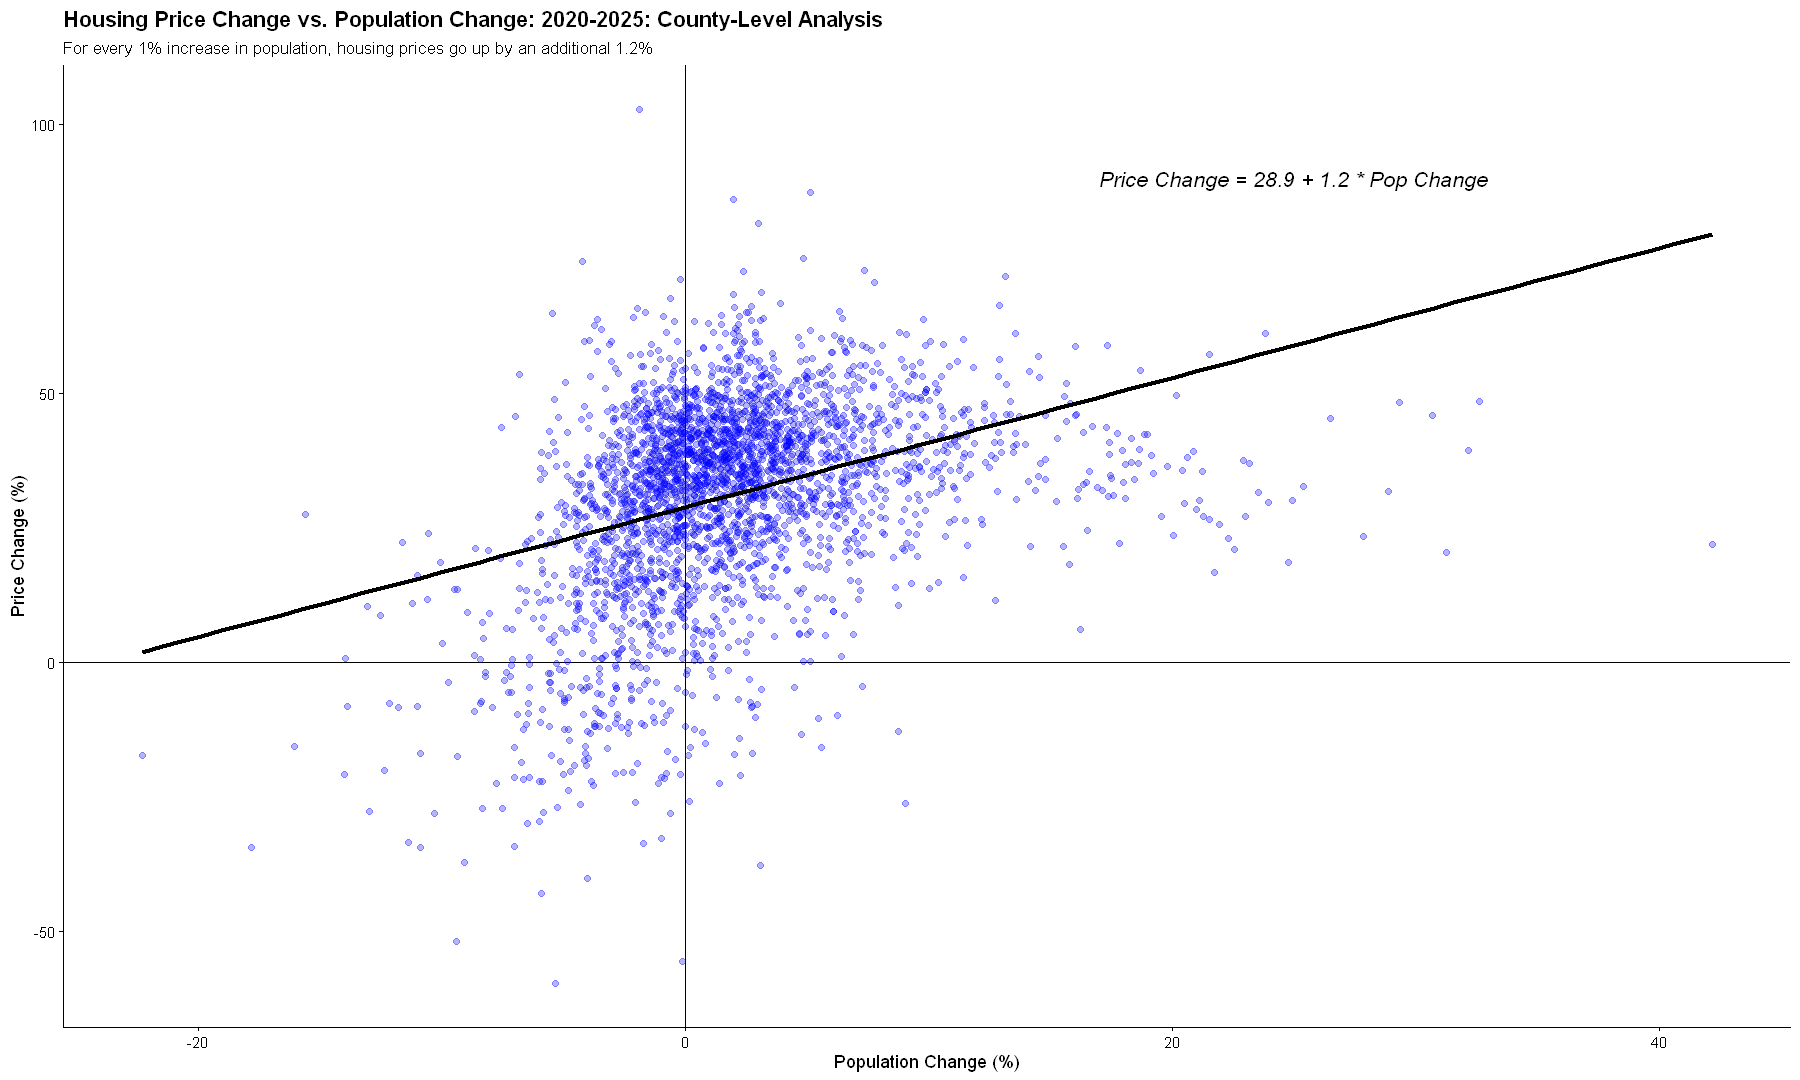

In [5]:
library(ggplot2)

ggplot(data, aes(x = pop_change, y = hp_change)) +
  
  # Reference lines at 0
  geom_hline(yintercept = 0, color = "black", linewidth = 0.5) +
  geom_vline(xintercept = 0, color = "black", linewidth = 0.5) +
  
  # Scatter points
  geom_point(color = "blue", alpha = 0.3, size = 1.5) +
  
  # Regression line
  geom_smooth(method = "lm", se = FALSE, color = "black", linewidth = 1.2) +
  
  # Equation label
  annotate("text", x = 25, y = 90,
           label = "Price Change = 28.9 + 1.2 * Pop Change",
           fontface = "italic", size = 4.5) +
  
  # Axis labels
  labs(
    title = "Housing Price Change vs. Population Change: 2020-2025: County-Level Analysis",
    subtitle = "For every 1% increase in population, housing prices go up by an additional 1.2%",
    x = "Population Change (%)",
    y = "Price Change (%)"
  ) +
  
  # Theme to match the slide
  theme_classic() +
  theme(
    plot.title   = element_text(face = "bold", size = 13),
    plot.subtitle = element_text(size = 10),
    axis.title   = element_text(size = 11)
  )

In [6]:
# Create counties in Arkansas
ar <- subset(data, grepl('Arkasnas', name))

`geom_smooth()` using formula = 'y ~ x'


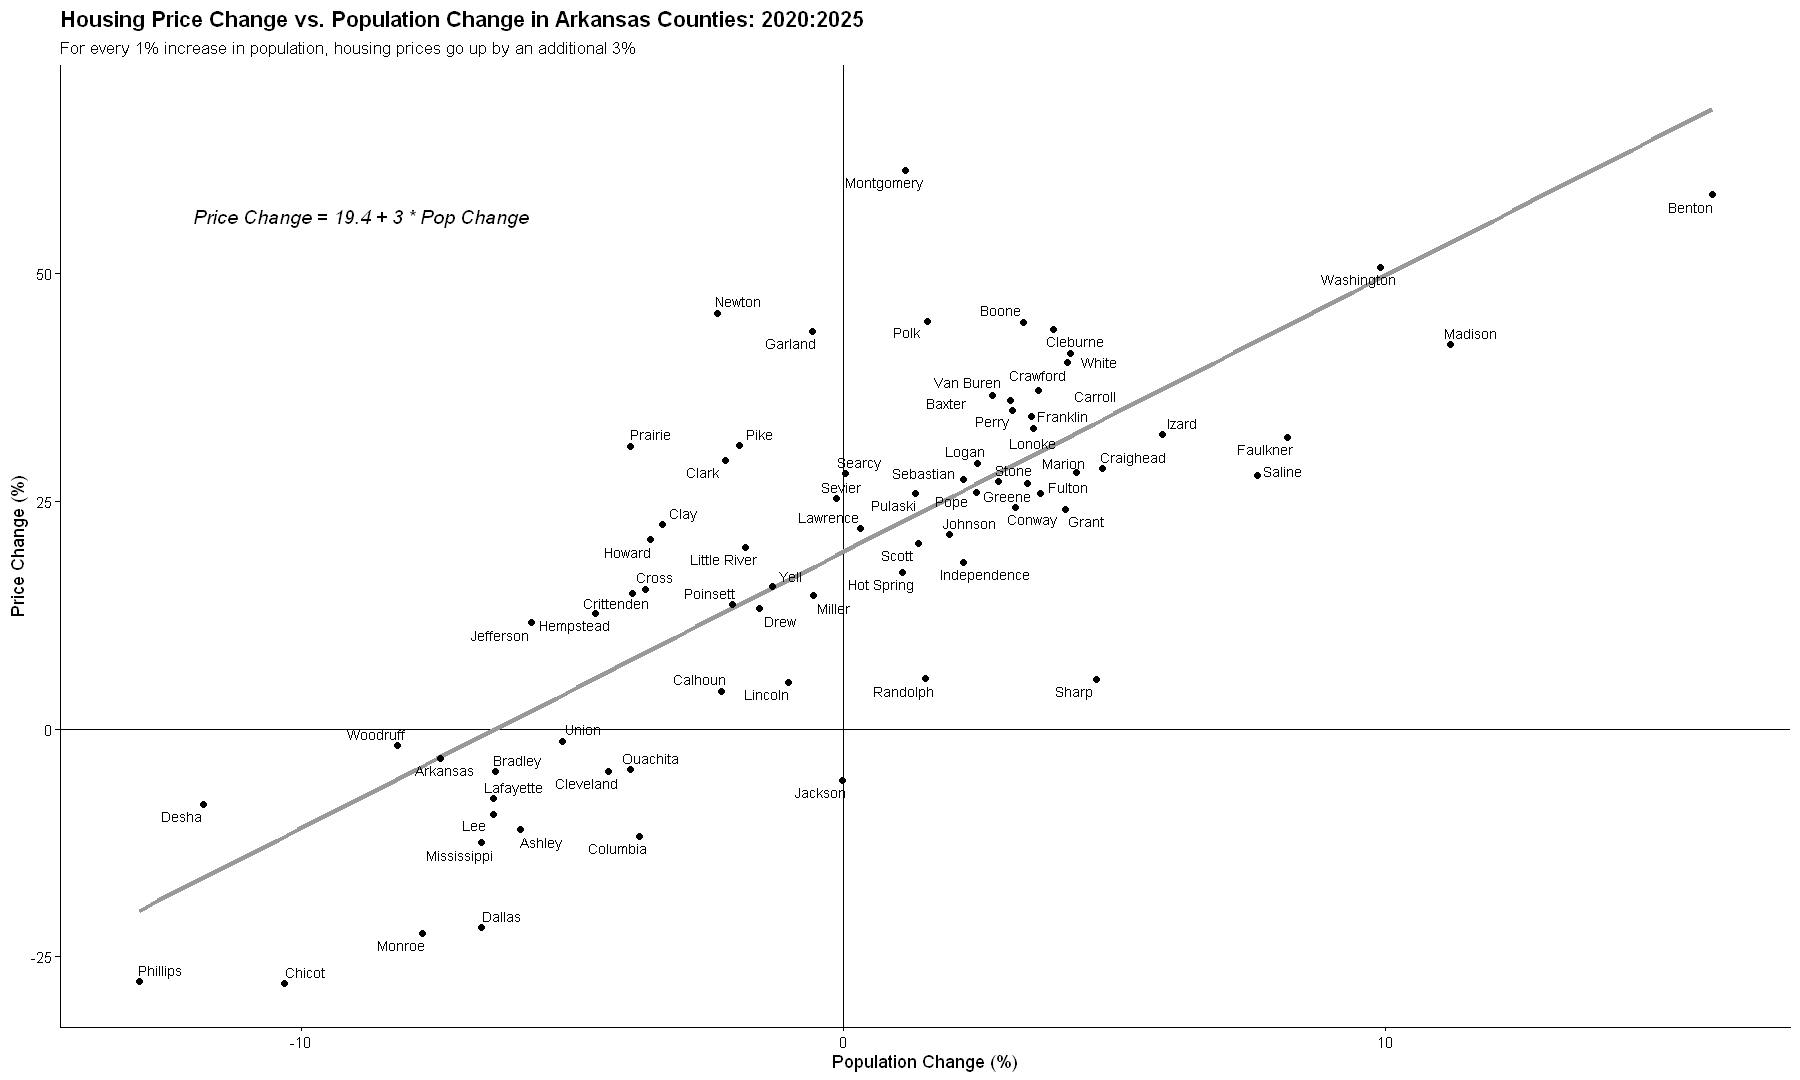

In [7]:
suppressWarnings(suppressMessages({
library(dplyr); library(ggplot2); library(readxl); library(ggrepel); options(warn = -1)

zillow_data = 'https://files.zillowstatic.com/research/public_csvs/zhvi/County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv?t=1775837851'
pop_data = 'https://www2.census.gov/programs-surveys/popest/tables/2020-2025/counties/totals/co-est2025-pop.xlsx'

housing = read.csv(zillow_data) %>% 
  mutate(State = state.name[match(State, state.abb)],
         name = paste0(RegionName, ', ', State)) %>%
  select(name, contains("12.31") & contains("202")) %>%
  rename_with(~ paste0("hp", 2020:2025), 2:7) %>% na.omit()

temp_file = tempfile(fileext = ".xlsx")
download.file(pop_data, destfile = temp_file, mode = "wb")
pop = read_xlsx(temp_file, skip = 3)[-1, -2] %>%
  rename_with(~ paste0("pop", 2020:2025), 2:7) %>% rename(name = 1) %>%
  mutate(name = gsub('^\\.', '', name)) %>% na.omit()
}))

housing$hp_change = ((housing$hp2025 - housing$hp2020) / housing$hp2020) * 100
pop$pop_change    = ((pop$pop2025  - pop$pop2020)  / pop$pop2020)  * 100

data = housing %>% left_join(pop, by = 'name') %>% na.omit()

# Arkansas subset — fix the typo from your original code
ar = subset(data, grepl('Arkansas', name))

# Strip ", Arkansas" for cleaner labels
ar$label = gsub(' County, Arkansas', '', ar$name)

# Fit Arkansas-only regression
model_ar = lm(hp_change ~ pop_change, data = ar)
coefs    = round(coef(model_ar), 1)

ggplot(ar, aes(x = pop_change, y = hp_change)) +

  geom_hline(yintercept = 0, color = "black", linewidth = 0.5) +
  geom_vline(xintercept = 0, color = "black", linewidth = 0.5) +

  geom_smooth(method = "lm", se = FALSE, color = "gray60", linewidth = 1.2) +

  geom_point(color = "black", size = 1.5) +

  geom_text_repel(aes(label = label), size = 3, max.overlaps = 100,
                  segment.color = NA, box.padding = 0.2) +

  annotate("text", 
           x = min(ar$pop_change, na.rm=TRUE) + 1, 
           y = max(ar$hp_change,  na.rm=TRUE) - 5,
           label = paste0("Price Change = ", coefs[1], " + ", coefs[2], " * Pop Change"),
           fontface = "italic", hjust = 0, size = 4) +

  labs(
    title    = "Housing Price Change vs. Population Change in Arkansas Counties: 2020:2025",
    subtitle = paste0("For every 1% increase in population, housing prices go up by an additional ", coefs[2], "%"),
    x = "Population Change (%)",
    y = "Price Change (%)"
  ) +

  theme_classic() +
  theme(
    plot.title    = element_text(face = "bold", size = 13),
    plot.subtitle = element_text(size = 10),
    axis.title    = element_text(size = 11)
  )